<a href="https://colab.research.google.com/github/Bilra-Hkr/DerielChaerahman_2411533007_ML2526/blob/main/Praktikum3/TugasLogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import library
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset form kaggle
dataset_url = 'https://raw.githubusercontent.com/Bilra-Hkr/DerielChaerahman_2411533007_ML2526/refs/heads/main/Praktikum2/Breast_cancer_data.csv'
data = pd.read_csv(dataset_url)

In [3]:
# Bagi dataset : fitur (X dan target (y)
X, y = data.drop(columns='diagnosis'), data['diagnosis']

# Bagi dataset : latih 70% dan uji 30%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=41)

In [4]:
# latih model tanpa scalling dataset
logreg_unscaled = LogisticRegression(random_state=41, max_iter=1000)
logreg_unscaled.fit(X_train, y_train)

y_pred_unscaled = logreg_unscaled.predict(X_test)
acc_unscaled = accuracy_score(y_test, y_pred_unscaled)
print('Sklearn Akurasi = ', acc_unscaled)

Sklearn Akurasi =  0.9473684210526315


In [5]:
# scalling dataset
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# scaling pada Data Latih/train
X_train_scaled = scaler.fit_transform(X_train)

# scaling pada Data Uji/test
X_test_scaled = scaler.transform(X_test)

#tidak perlu scalling pada data latih (y) karena sudah bernilai biner(1,0)

# Latih model menggunakan data scalling
logreg_scaled = LogisticRegression(random_state=41, max_iter=1000)
logreg_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = logreg_scaled.predict(X_test_scaled)
acc_scaled = accuracy_score(y_test, y_pred_scaled)
print('Sklearn Akurasi = ', acc_scaled)

Sklearn Akurasi =  0.9590643274853801


In [11]:
# Cetak Akurasi
print(f"Akurasi tidak scaling : {acc_unscaled:.4f}")
print(f"Akurasi dengan scaling: {acc_scaled:.4f}\n")

Akurasi tidak scaling : 0.9474
Akurasi dengan scaling: 0.9591



Text(0.5, 427.9555555555555, 'Predicted label')

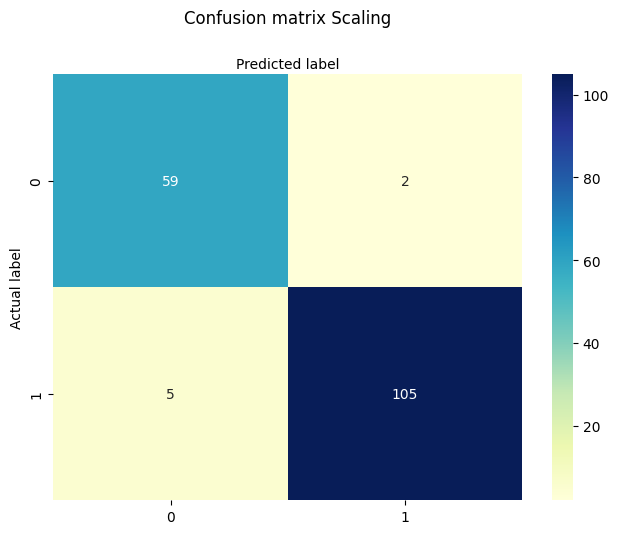

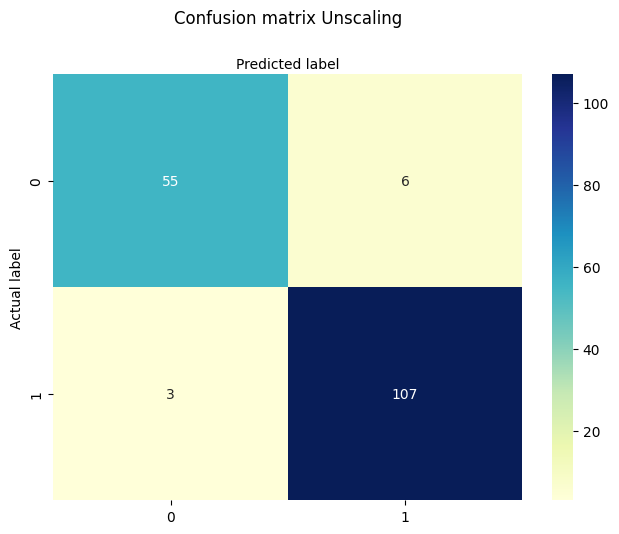

In [19]:
# cetak cunfusion matrix
# scaling dataset
cnf_matrix = confusion_matrix(y_test, y_pred_scaled)
cnf_matrix

class_names = [0,1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix Scaling', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

# unscaling dataset
cnf_matrix = confusion_matrix(y_test, y_pred_unscaled)
cnf_matrix

class_names = [0,1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix Unscaling', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [7]:
# Mengambil nilai probabilitas
y_probs = logreg_scaled.predict_proba(X_test_scaled)[:, 1]

thresholds = [0.3, 0.5, 0.7]

for t in thresholds:
    # Jika probabilitas >= threshold, jadikan kelas 1, selain itu 0
    y_pred_custom = (y_probs >= t).astype(int)

    print(f"\nEvaluasi untuk Threshold = {t}")
    print(classification_report(y_test, y_pred_custom))


Evaluasi untuk Threshold = 0.3
              precision    recall  f1-score   support

           0       1.00      0.87      0.93        61
           1       0.93      1.00      0.96       110

    accuracy                           0.95       171
   macro avg       0.97      0.93      0.95       171
weighted avg       0.96      0.95      0.95       171


Evaluasi untuk Threshold = 0.5
              precision    recall  f1-score   support

           0       0.92      0.97      0.94        61
           1       0.98      0.95      0.97       110

    accuracy                           0.96       171
   macro avg       0.95      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171


Evaluasi untuk Threshold = 0.7
              precision    recall  f1-score   support

           0       0.82      0.98      0.90        61
           1       0.99      0.88      0.93       110

    accuracy                           0.92       171
   macro avg       0.91      0.9